In [1]:
import sys; sys.path.insert(0, '..')
import torch
import matplotlib.pyplot as plt
from src.spatial_analysis import compute_feature_spatial_variances

DEVICE = 'cuda'  # change to 'cpu' if no GPU

ckpt4  = torch.load('../checkpoints/sae_layer4.pt',  map_location='cpu', weights_only=False)
ckpt8  = torch.load('../checkpoints/sae_layer8.pt',  map_location='cpu', weights_only=False)
ckpt12 = torch.load('../checkpoints/sae_layer12.pt', map_location='cpu', weights_only=False)
print('Checkpoints loaded')

Checkpoints loaded


In [2]:
print('Computing spatial variances (100k tokens per layer)...')
sv4  = compute_feature_spatial_variances('../data/layer4_activations.pt',  ckpt4,  device=DEVICE)
sv8  = compute_feature_spatial_variances('../data/layer8_activations.pt',  ckpt8,  device=DEVICE)
sv12 = compute_feature_spatial_variances('../data/layer12_activations.pt', ckpt12, device=DEVICE)

torch.save({'layer4': sv4, 'layer8': sv8, 'layer12': sv12},
           '../checkpoints/spatial_variances.pt')
print(f'Layer 4  mean_var={sv4.mean():.3f}  median={sv4.median():.3f}')
print(f'Layer 8  mean_var={sv8.mean():.3f}  median={sv8.median():.3f}')
print(f'Layer 12 mean_var={sv12.mean():.3f}  median={sv12.median():.3f}')

Computing spatial variances (100k tokens per layer)...
Layer 4  mean_var=15.609  median=14.890
Layer 8  mean_var=20.216  median=19.220
Layer 12 mean_var=21.627  median=20.420


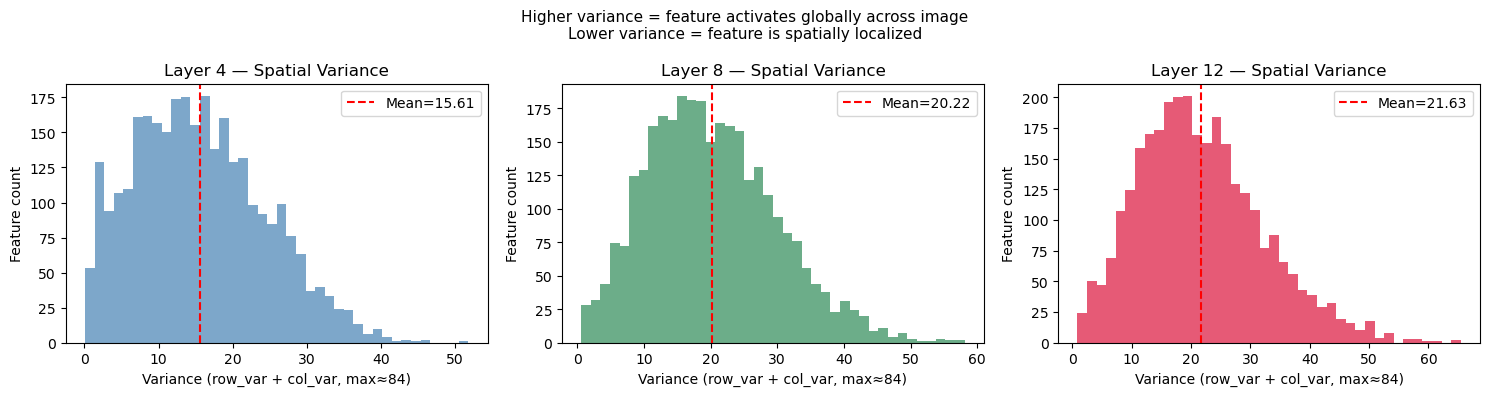

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('Layer 4', sv4, 'steelblue'), ('Layer 8', sv8, 'seagreen'), ('Layer 12', sv12, 'crimson')]

for ax, (name, sv, color) in zip(axes, pairs):
    ax.hist(sv.numpy(), bins=40, color=color, alpha=0.7)
    ax.axvline(sv.mean().item(), color='red', linestyle='--',
               label=f'Mean={sv.mean():.2f}')
    ax.set_title(f'{name} — Spatial Variance')
    ax.set_xlabel('Variance (row_var + col_var, max≈84)')
    ax.set_ylabel('Feature count')
    ax.legend()

plt.suptitle('Higher variance = feature activates globally across image\nLower variance = feature is spatially localized', fontsize=11)
plt.tight_layout()
plt.savefig('../checkpoints/spatial_variance_distribution.png', dpi=150)
plt.show()

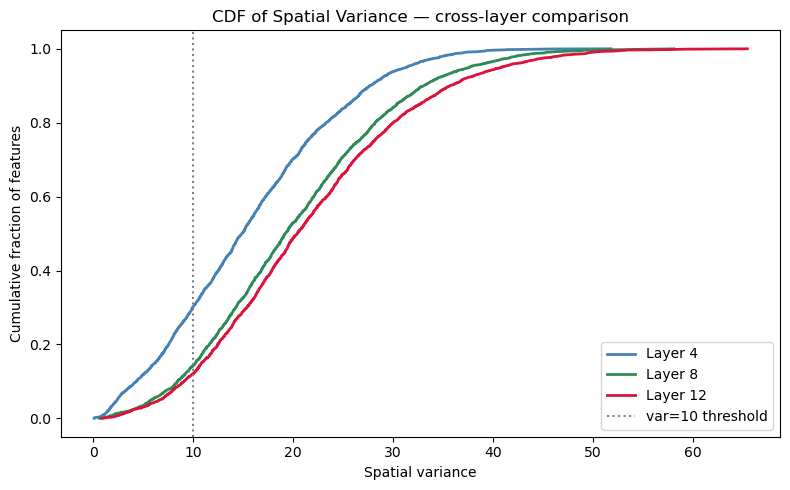

In [4]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))
for name, sv, color in pairs:
    sorted_sv = np.sort(sv.numpy())
    cdf = np.arange(1, len(sorted_sv) + 1) / len(sorted_sv)
    ax.plot(sorted_sv, cdf, label=name, color=color, linewidth=2)

ax.axvline(10, color='gray', linestyle=':', label='var=10 threshold')
ax.set_xlabel('Spatial variance')
ax.set_ylabel('Cumulative fraction of features')
ax.set_title('CDF of Spatial Variance — cross-layer comparison')
ax.legend()
plt.tight_layout()
plt.savefig('../checkpoints/spatial_variance_cdf.png', dpi=150)
plt.show()

In [5]:
print(f"{'Layer':<12} {'Mean var':>10} {'% Global (>10)':>16} {'% Local (<3)':>14}")
print('-' * 55)
for name, sv in [('Layer 4', sv4), ('Layer 8', sv8), ('Layer 12', sv12)]:
    pct_global = 100 * (sv > 10).float().mean().item()
    pct_local  = 100 * (sv < 3).float().mean().item()
    print(f'{name:<12} {sv.mean().item():>10.3f} {pct_global:>16.1f}% {pct_local:>14.1f}%')

Layer          Mean var   % Global (>10)   % Local (<3)
-------------------------------------------------------
Layer 4          15.609             69.8%            6.9%
Layer 8          20.216             85.8%            1.7%
Layer 12         21.627             88.0%            1.2%
